In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import run_logit, split_test_train

In [2]:
X_train = np.loadtxt("gisette/GISETTE/gisette_train.data")
y_train = np.loadtxt("gisette/GISETTE/gisette_train.labels")
X_test = np.loadtxt("gisette/GISETTE/gisette_valid.data")
y_test = np.loadtxt("gisette/gisette_valid.labels")

In [7]:
print(X_train.shape)

(6000, 5000)


In [9]:
# Setup
random_state=50
num_iter=100
rng=np.random.default_rng(random_state)
p_vals = np.linspace(50,5000,30).astype(int)
n_vals = p_vals*6000/5000
kappas = p_vals/n_vals

In [7]:
print(kappas)

[0.83333333 0.83333333 0.83333333 0.83333333 0.83333333 0.83333333
 0.83333333 0.83333333 0.83333333 0.83333333 0.83333333 0.83333333
 0.83333333 0.83333333 0.83333333 0.83333333 0.83333333 0.83333333
 0.83333333 0.83333333 0.83333333 0.83333333 0.83333333 0.83333333
 0.83333333 0.83333333 0.83333333 0.83333333 0.83333333 0.83333333]


0/30


c:\Users\lando\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\lando\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

1/30
2/30
3/30
4/30
5/30
6/30
7/30
8/30
9/30
10/30
11/30
12/30
13/30
14/30
15/30
16/30
17/30
18/30
19/30
20/30
21/30
22/30
23/30
24/30
25/30
26/30
27/30
28/30
29/30


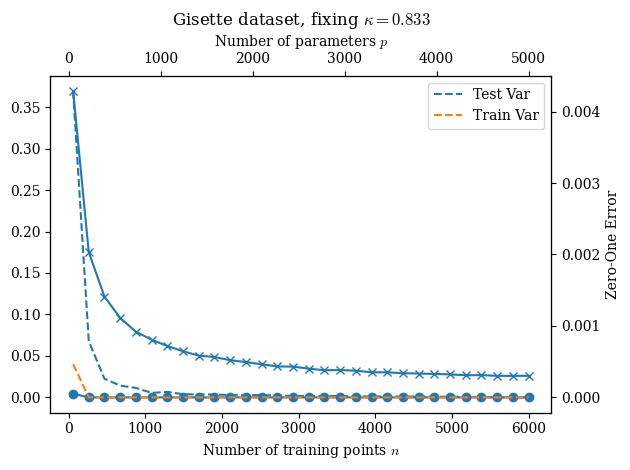

In [ ]:
train_errors=[]
train_error_vars=[]
test_errors=[]
test_error_vars=[]
for n_idx,n in enumerate(n_vals):
    print(f'{n_idx}/{len(n_vals)}')
    p = p_vals[n_idx]
    listy_test=np.zeros(num_iter)
    listy_train=np.zeros(num_iter)
    for t in range(num_iter):

        X_train_t, y_train_t, X_test_t, y_test_t, selected_cols = split_test_train(X_train,y_train,int(p),int(n),rng)
        errors = run_logit(X_train_t,y_train_t,X_test[:, selected_cols],y_test)
        listy_train[t]=(errors["train_error"])
        listy_test[t]=(errors["test_error"])
    train_errors.append(np.mean(listy_train))
    train_error_vars.append(np.var(listy_train))
    test_errors.append(np.mean(listy_test))
    test_error_vars.append(np.var(listy_test))

plt.rcParams.update({'font.family': 'serif','mathtext.fontset': 'cm',})

fig,ax=plt.subplots()
line1,= ax.plot(n_vals,test_errors,marker='x',label='Train')
plt.ylabel('Zero-One Error')
ax.set_xlabel('Number of training points $n$')
ax2=ax.twiny()
line2,= ax2.plot(p_vals,train_errors,marker='o')
ax2.set_xlabel('Number of parameters $p$')
ax3=ax.twinx()
line3,= ax3.plot(n_vals,test_error_vars,'--',label='Test Var')
ax3.set_ylabel('Error Variance')
line4,= ax3.plot(n_vals,train_error_vars,'--',label='Train Var')

plt.title(r'Gisette dataset, fixing $\kappa=0.833$')
plt.legend()
plt.tight_layout()
plt.savefig('gisette_fixed_kappa=.83.png',dpi=400)



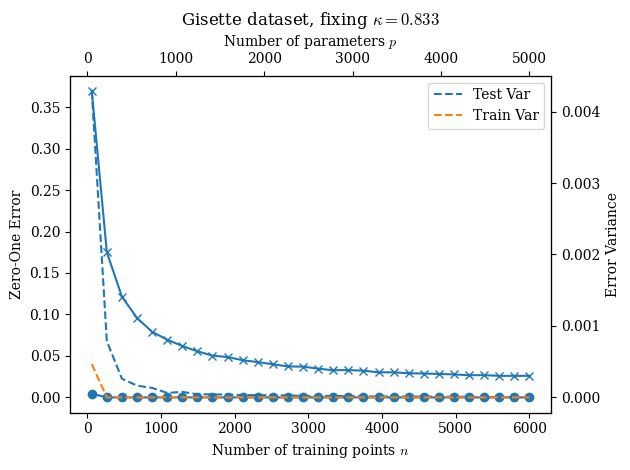

In [13]:
plt.rcParams.update({'font.family': 'serif','mathtext.fontset': 'cm',})

fig,ax=plt.subplots()
line1,= ax.plot(n_vals,test_errors,marker='x',label='Train')
plt.ylabel('Zero-One Error')
ax.set_xlabel('Number of training points $n$')
ax2=ax.twiny()
line2,= ax2.plot(p_vals,train_errors,marker='o')
ax2.set_xlabel('Number of parameters $p$')
ax3=ax.twinx()
line3,= ax3.plot(n_vals,test_error_vars,'--',label='Test Var')
ax3.set_ylabel('Error Variance')
line4,= ax3.plot(n_vals,train_error_vars,'--',label='Train Var')

plt.title(r'Gisette dataset, fixing $\kappa=0.833$')
plt.legend()
plt.tight_layout()
plt.savefig('gisette_fixed_kappa=.83.png',dpi=400)
